In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
auto = pd.read_csv('data/05-automobile.csv')
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,...,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,3,115.0,alfa-romero,gas,std,two,rwd,front,88.6,168.8,...,111.0,5000.0,21,27,13495.0,1,0,0,0,0
1,3,115.0,alfa-romero,gas,std,two,rwd,front,88.6,168.8,...,111.0,5000.0,21,27,16500.0,1,0,0,0,0
2,1,115.0,alfa-romero,gas,std,two,rwd,front,94.5,171.2,...,154.0,5000.0,19,26,16500.0,0,0,1,0,0
3,2,164.0,audi,gas,std,four,fwd,front,99.8,176.6,...,102.0,5500.0,24,30,13950.0,0,0,0,1,0
4,2,164.0,audi,gas,std,four,4wd,front,99.4,176.6,...,115.0,5500.0,18,22,17450.0,0,0,0,1,0


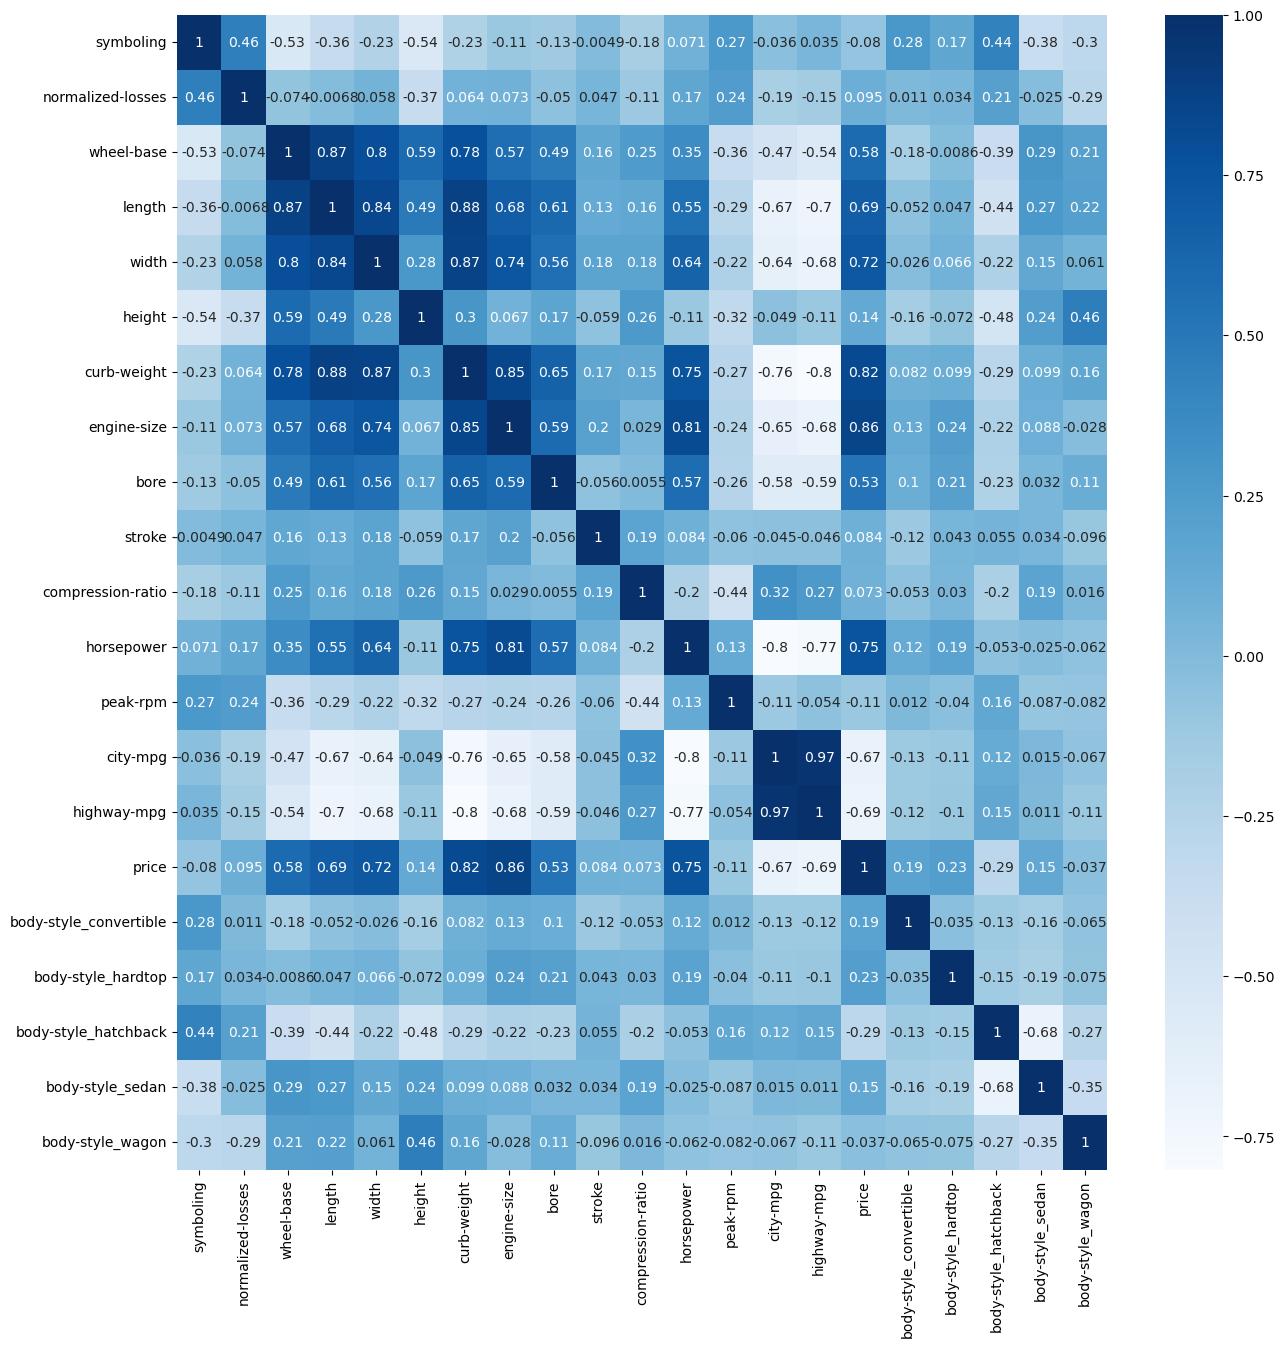

In [3]:
# Pairwise correlations
numeric_df = auto.select_dtypes(include=['number'])

plt.figure(figsize=(15,15))
sns.heatmap(numeric_df.corr(), cbar=True, annot=True, cmap='Blues');
plt.show()

## Linear regression

In [4]:
X = auto[['engine-size']]
y = auto['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

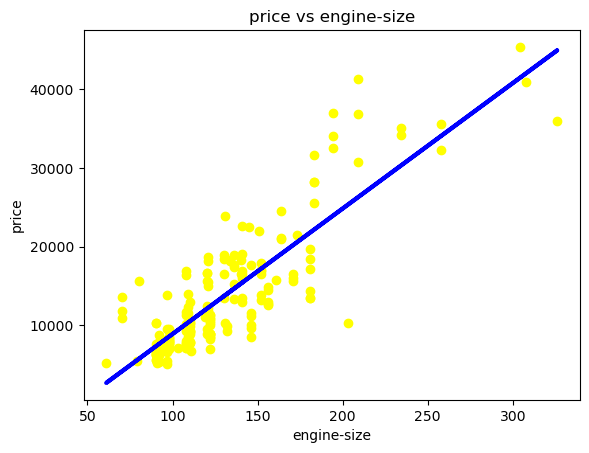

In [6]:
# plot data and prediction
plt.scatter(auto['engine-size'], auto['price'],  color='yellow')
plt.plot(auto['engine-size'], model.predict(auto[['engine-size']]), 
         color='blue', linewidth=3)

plt.title("price vs engine-size") # stating the title of the graph
plt.xlabel("engine-size") # adding the name of x-axis
plt.ylabel("price") # adding the name of y-axis
plt.show()

In [7]:
print("lr.intercept_:", model.intercept_) # b0
print("lr.coef_:", model.coef_) # b1

lr.intercept_: -7072.849877076562
lr.coef_: [159.60160042]


In [8]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('MAE:', mae)
print('R^2:', r2)

RMSE: 3974.5636110233722
MAE: 2766.0318100161526
R^2: 0.7986171722228957


## Multiple linear regression

In [9]:
X = auto[['engine-size', 'curb-weight']]
y = auto['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("lr.intercept_:", model.intercept_) # b0
print("lr.coef_:", model.coef_) # b1, b2

lr.intercept_: -13159.134165371906
lr.coef_: [106.84232588   4.98968626]


In [11]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('MAE:', mae)
print('R^2:', r2)

RMSE: 3866.515133695743
MAE: 2671.8111112138554
R^2: 0.809417526385974


In [12]:
# Multiple regression with dummy variable
model.fit(auto[['engine-size', 'curb-weight', 'body-style_convertible', 
               'body-style_hardtop', 'body-style_hatchback', 'body-style_sedan', 
               'body-style_wagon']], auto['price'])

print("lr.intercept_:", model.intercept_) # b0
print("lr.coef_:", model.coef_) 

lr.intercept_: -12352.249989314712
lr.coef_: [   92.01392495     5.83545983  3432.21483545  1942.00644001
 -1909.80071319  -546.30541652 -2918.11514575]


## Regularization (Ridge & Lasso)

In [13]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

r2 = r2_score(y_test, ridge_pred)
print('Ridge R^2:', r2)

r2 = r2_score(y_test, lasso_pred)
print('Lasso R^2:', r2)

Ridge R^2: 0.8089341993383288
Lasso R^2: 0.809420223946287
